# Composing source models

Stars rarely come alone. A young star may be ringed by the hot inner rim of its disk; a companion may carry its own envelope of accreting material; a close binary may sit inside a circumbinary ring. None of these is "a binary" or "a disk", and writing a bespoke model class for every new combination is tedious and easy to get wrong.

This tutorial shows how to build scenes like these out of simple shapes. Our running example is a young star with a bright, lopsided inner rim, observed with aperture masking. We want to know whether a faint protoplanet is hiding next to it.

This is a real problem, not a toy one. In LkCa 15, for example, candidate protoplanets found with sparse aperture masking (Kraus & Ireland 2012; Sallum et al. 2015) were later argued to be consistent with light from the disk itself (Currie et al. 2019). If the disk and the planet can be fitted *together*, that kind of question can be answered with the data rather than argued about afterwards.

In [1]:
import sys
from itertools import combinations
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from drpangloss.grid_fit import (
    best_grid_point,
    laplace_contrast_uncertainty_grid,
    likelihood_grid,
    optimized_contrast_grid,
)
from drpangloss.models import (
    BinaryModelCartesian,
    GaussianDisk,
    ModulatedGaussianRim,
    PointSource,
    System,
    UniformDisk,
    laplace_cov,
    numpyro_model,
)
from drpangloss.oidata import OIData, cp_indices
from drpangloss.plotting import plot_likelihood_grid, plot_model, set_style

set_style()  # the figure style used throughout the docs

## Shapes

`drpangloss` currently offers four shapes: an unresolved `PointSource`, a `GaussianDisk`, a `UniformDisk`, and a `ModulatedGaussianRim`, which is a thin ring that can be blurred, inclined and made brighter on one side.

Every shape has three placement parameters. `dra` and `ddec` are offsets in milliarcseconds, positive to the East and North. `flux` says how bright the shape is *relative to the other parts of a scene*. On its own, every shape is normalized to unit flux, so a lone shape's `flux` has no effect.

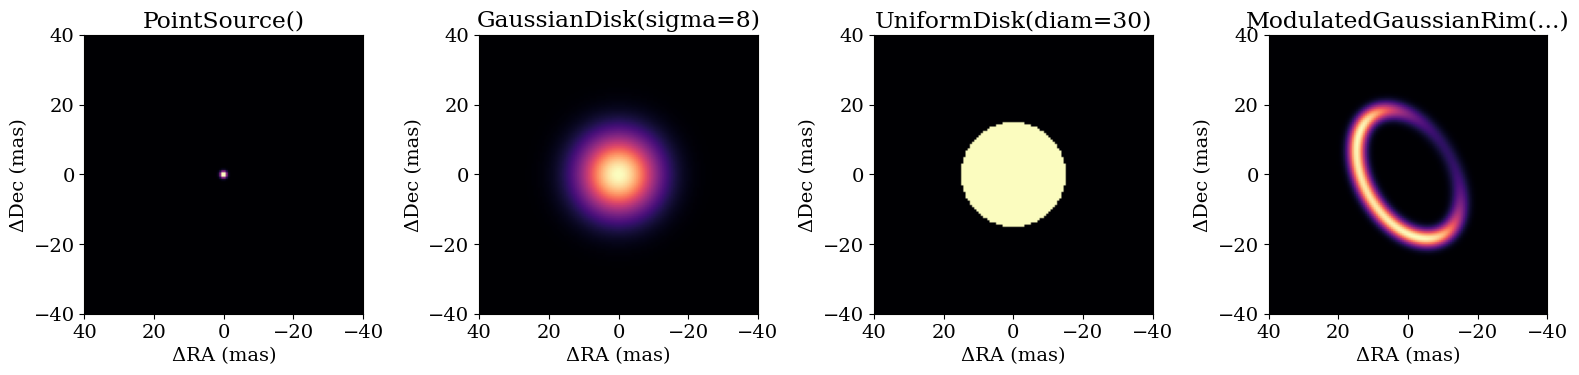

In [2]:
shapes = {
    "PointSource()": PointSource(),
    "GaussianDisk(sigma=8)": GaussianDisk(sigma=8.0),
    "UniformDisk(diam=30)": UniformDisk(diam=30.0),
    "ModulatedGaussianRim(...)": ModulatedGaussianRim(
        diam=40.0, fwhm=4.0, inc=50.0, pa=30.0, az_amps=0.7, az_pas=120.0
    ),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (title, shape) in zip(axes, shapes.items()):
    plot_model(shape, fov_mas=80.0, npix=128, ax=ax, title=title)
plt.tight_layout()
plt.show()

The rim is inclined by 50°, with its major axis at a position angle of 30° East of North, and a first-order brightness modulation makes the side at position angle 120° brighter. `plot_model` draws every image with East to the left and North up, the usual orientation on the sky.

## A simulated observation

We'll simulate a nine-hole aperture mask observing at 1.65 µm, with 1% errors on the squared visibilities and 0.3° errors on the closure phases. This is just a random mask; with real data, you would load an OIFITS file into `OIData` instead.

In [3]:
rng = np.random.default_rng(3)
holes = rng.uniform(-3.5, 3.5, size=(9, 2))
pairs = np.array(list(combinations(range(9), 2)))
triangles = np.array(list(combinations(range(9), 3)))
i_cps1, i_cps2, i_cps3 = cp_indices(pairs, triangles)
baselines = holes[pairs[:, 1]] - holes[pairs[:, 0]]

observation = OIData(
    {
        "u": jnp.array(baselines[:, 0]),
        "v": jnp.array(baselines[:, 1]),
        "wavel": jnp.array([1.65e-6]),
        "vis": jnp.ones(len(pairs)),
        "d_vis": jnp.full(len(pairs), 0.01),
        "phi": jnp.zeros(len(triangles)),
        "d_phi": jnp.full(len(triangles), 0.3),
        "phi_unit": "deg",
        "i_cps1": i_cps1,
        "i_cps2": i_cps2,
        "i_cps3": i_cps3,
        "v2_flag": True,
        "cp_flag": True,
    }
)
print(f"{len(pairs)} baselines and {len(triangles)} closure phases")

36 baselines and 84 closure phases


## Mixing shapes into a `System`

A `System` is a scene made of named parts. Its visibility is the flux-weighted average of theirs,

$$V = \frac{\sum_i f_i V_i}{\sum_i f_i}.$$

Dividing by the total flux reflects how interferometric data work: visibilities are normalized to one at zero baseline, so we can only ever measure how bright the parts are *compared to each other*, never in absolute terms. The convention is therefore to keep one reference part (usually the star) at `flux=1`. Every other `flux` is then a flux ratio relative to the star.

The simplest scene is a binary: a star and a fainter point source. `drpangloss` has always had a dedicated `BinaryModelCartesian` for this, and a `System` gives the same answer:

In [4]:
binary = BinaryModelCartesian(dra=60.0, ddec=-40.0, flux=0.02)
same_binary = System(
    star=PointSource(),
    comp=PointSource(dra=60.0, ddec=-40.0, flux=0.02),
)

difference = jnp.max(
    jnp.abs(observation.model(binary) - observation.model(same_binary))
)
print(same_binary)
print(f"largest difference in observables: {float(difference):.1e}")

System(
    star=PointSource(flux=1, dra=0, ddec=0),
    comp=PointSource(flux=0.02, dra=60, ddec=-40),
    flux=1,
    dra=0,
    ddec=0,
)
largest difference in observables: 1.2e-07


The difference is at the level of float32 rounding. For a plain binary, keep using `BinaryModelCartesian` or `BinaryModelAngular`. They are the fastest option, and the binary tutorials all still apply. If you start from a binary and later need more, `binary.to_system()` returns this `System` form for you to extend.

## Our young star

Now the star from the introduction. The rim is the same one as above; we give it half the star's flux, so `flux=0.5`:

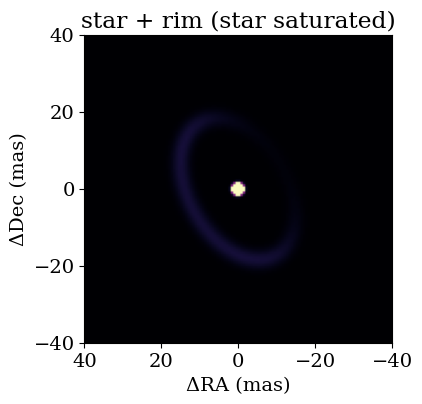

In [5]:
rim = ModulatedGaussianRim(
    diam=40.0, fwhm=4.0, inc=50.0, pa=30.0, az_amps=0.7, az_pas=120.0, flux=0.5
)
young_star = System(star=PointSource(), rim=rim)

plot_model(
    young_star,
    fov_mas=80.0,
    npix=128,
    saturate=0.999,
    title="star + rim (star saturated)",
)
plt.show()

The star holds two thirds of the light in a single pixel, so the colour scale is saturated to make the rim visible.

## A companion with its own disk

A `System` can itself be a part of a larger `System`. Suppose the protoplanet is surrounded by its own circumplanetary material: a point-like core, plus a small Gaussian disk with half the core's flux. We group those into a sub-system and give the whole group 30% of the star's flux. That is far brighter than any real protoplanet, but it makes the picture easy to read.

The sub-system's own `dra` and `ddec` place the whole group, so moving the companion means changing two numbers rather than one per part.

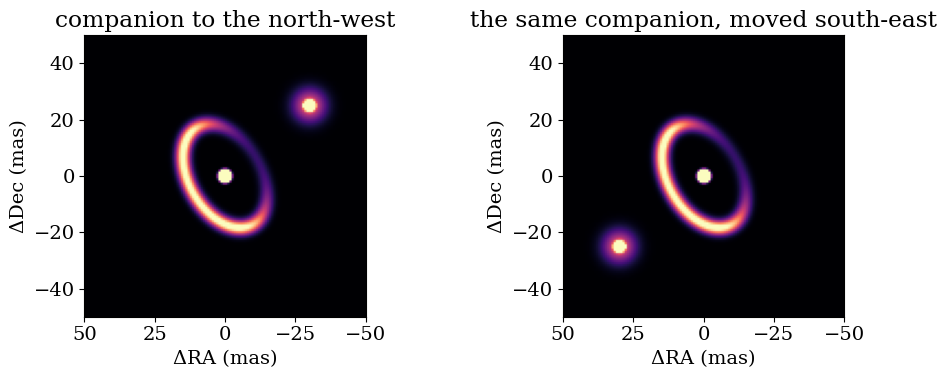

In [6]:
companion = System(
    core=PointSource(),
    disk=GaussianDisk(sigma=4.0, flux=0.5),
    dra=-30.0,
    ddec=25.0,
    flux=0.3,
)
scene = System(star=PointSource(), rim=rim, comp=companion)
moved = scene.set(["comp.dra", "comp.ddec"], [30.0, -25.0])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_model(scene, 100.0, npix=128, ax=axes[0], saturate=0.99, title="companion to the north-west")
plot_model(moved, 100.0, npix=128, ax=axes[1], saturate=0.99, title="the same companion, moved south-east")
plt.tight_layout()
plt.show()

## Naming parameters

The names you give the parts are more than labels: they are how you refer to parameters from now on. Every parameter has a **path** made of names joined by dots, such as `"comp.flux"` or `"comp.disk.sigma"`. You can read a parameter as an attribute or with `get`. To change one, use `set`, which returns a new model and leaves the original untouched.

In [7]:
print(f"scene.comp.disk.sigma  = {float(scene.comp.disk.sigma):g}")
print(f"scene.get('comp.flux') = {float(scene.get('comp.flux')):g}")

brighter = scene.set("comp.flux", 0.6)
print(f"original comp.flux     = {float(scene.comp.flux):g}")
print(f"brighter comp.flux     = {float(brighter.comp.flux):g}")

scene.comp.disk.sigma  = 4
scene.get('comp.flux') = 0.3
original comp.flux     = 0.3
brighter comp.flux     = 0.6


Because these paths are what the fitting tools take as input, it's worth choosing names that will still make sense when you read a corner plot six months from now.

## Is there a planet?

Now for the real question. We simulate data from a star, the rim, and a faint point-like companion with 1% of the star's flux, and then pretend we don't know about the companion.

To search for it, we give the grid tools a **template**: a model that describes the scene we're testing, with a companion whose position and brightness will be varied. The grid is a dictionary keyed by the paths of the parameters to vary. These are the same functions used in the binary tutorials; only the template and the parameter names are new.

For now we hold the rim fixed at its true shape. That's optimistic, and we'll let it vary in the next-but-one section.

best grid point: {'comp.dra': 43.3333, 'comp.ddec': 33.3333, 'comp.flux': 0.01}


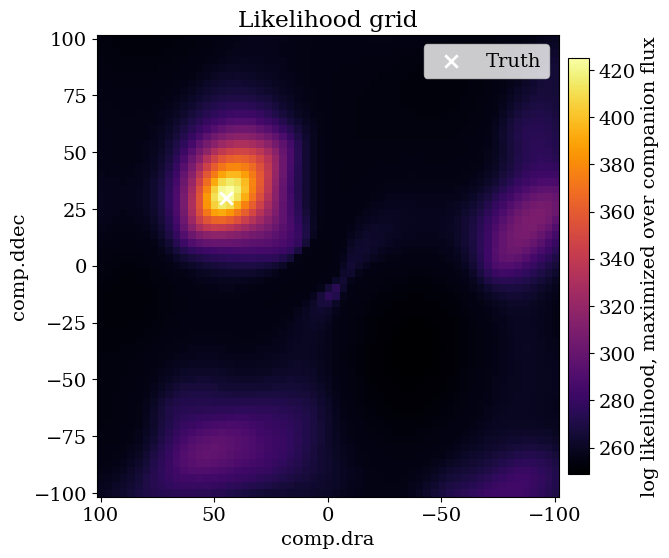

In [8]:
truth = System(
    star=PointSource(),
    rim=rim,
    comp=PointSource(dra=45.0, ddec=30.0, flux=0.01),
)
data = observation.with_model(truth, key=jax.random.PRNGKey(0))

search = System(star=PointSource(), rim=rim, comp=PointSource(flux=1e-3))
grid = {
    "comp.dra": jnp.linspace(-100.0, 100.0, 61),
    "comp.ddec": jnp.linspace(-100.0, 100.0, 61),
    "comp.flux": 10.0 ** jnp.linspace(-3.5, -1.0, 16),
}
loglike_grid = likelihood_grid(data, search, grid)

best = best_grid_point(loglike_grid, grid)
print("best grid point:", {path: round(value, 4) for path, value in best.items()})

truth_position = {"comp.dra": 45.0, "comp.ddec": 30.0}
plot_likelihood_grid(
    loglike_grid.max(axis=2),
    grid,
    truths=truth_position,
    flux_param="comp.flux",
    colorbar_label="log likelihood, maximized over companion flux",
)
plt.show()

The brightest peak sits on the true position. The fainter peaks are aliases: with only 36 baselines, the mask can't tell some positions apart very well.

## How significant is it?

A likelihood peak is not yet a detection. `optimized_contrast_grid` finds the best-fitting companion flux at every position, and `laplace_contrast_uncertainty_grid` estimates the uncertainty on that flux. Their ratio is a map of detection significance.

Both functions need to know which parameter is the brightness to optimize and which are the coordinates of the map; `flux_param` tells them.

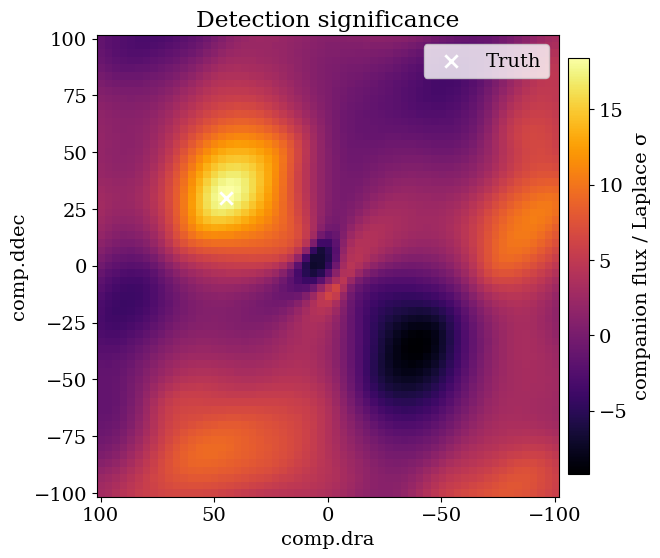

In [9]:
best_flux = optimized_contrast_grid(data, search, grid, flux_param="comp.flux")
best_flux_indices = jnp.argmax(loglike_grid, axis=2)
flux_sigma = laplace_contrast_uncertainty_grid(
    best_flux_indices, data, search, grid, flux_param="comp.flux"
)
significance = best_flux / flux_sigma

fig, ax = plot_likelihood_grid(
    significance,
    grid,
    truths=truth_position,
    flux_param="comp.flux",
    colorbar_label="companion flux / Laplace σ",
)
ax.set_title("Detection significance")
plt.show()

The companion stands out clearly above the aliases. The dark patch at the mirror-image position is worth understanding. A companion on the opposite side of the star would produce closure phases of the opposite sign, so there the data are best matched by *less* light than the star alone, and the best-fit flux is negative. Real fluxes can't be negative, and `drpangloss` won't let you build a model with one. The optimizer reports the unconstrained estimate anyway, because that is what the Ruffio et al. (2018) upper limits in the contrast-limits tutorial are built from; they apply the positivity prior at that stage. So read a significance map for its positive peaks.

## Letting the rim vary: Laplace and HMC

So far we've assumed we know the rim exactly, which is never true. A companion search is only trustworthy if a slightly different rim couldn't explain the same signal. With a composed model this costs almost nothing extra: we just add the rim's parameters to the list of things to fit.

`laplace_cov` gives a quick Gaussian estimate of the uncertainties from the curvature of the likelihood at the best fit. For a full posterior, `numpyro_model` turns the template and a dictionary of `{path: prior}` into a numpyro model, using each path as the name of a sample site. Neither needs a hand-written model function.

In [10]:
priors = {
    "comp.dra": dist.Uniform(-100.0, 100.0),
    "comp.ddec": dist.Uniform(-100.0, 100.0),
    "comp.flux": dist.LogUniform(1e-4, 1e-1),
    "rim.flux": dist.Uniform(0.2, 1.0),
    "rim.diam": dist.Uniform(30.0, 50.0),
}
paths = list(priors)
start = {**best, "rim.flux": 0.5, "rim.diam": 40.0}

covariance = laplace_cov(jnp.array([start[p] for p in paths]), paths, data, search)
laplace_sigma = dict(zip(paths, np.sqrt(np.diag(covariance))))

# For comparison: the same estimate with the rim held fixed at its true shape.
comp_paths = list(grid)
fixed_covariance = laplace_cov(jnp.array([best[p] for p in comp_paths]), comp_paths, data, search)
fixed_sigma = dict(zip(comp_paths, np.sqrt(np.diag(fixed_covariance))))

kernel = NUTS(
    numpyro_model(search, priors, data),
    init_strategy=init_to_value(values=start),
)
mcmc = MCMC(kernel, num_warmup=300, num_samples=500, progress_bar=False)
mcmc.run(jax.random.PRNGKey(1))
posterior = mcmc.get_samples()

truth_values = {path: float(truth.get(path)) for path in paths}
print(f"{'parameter':10s} {'truth':>8s} {'HMC':>18s} {'Laplace σ':>10s} {'σ, rim fixed':>13s}")
for path in paths:
    samples = posterior[path]
    fixed = f"{fixed_sigma[path]:13.4f}" if path in fixed_sigma else f"{'-':>13s}"
    print(
        f"{path:10s} {truth_values[path]:8.4f} "
        f"{float(jnp.median(samples)):9.4f} ± {float(jnp.std(samples)):.4f} "
        f"{laplace_sigma[path]:10.4f} {fixed}"
    )

parameter     truth                HMC  Laplace σ  σ, rim fixed
comp.dra    45.0000   44.9272 ± 1.0927     1.0649        1.0422
comp.ddec   30.0000   32.6506 ± 1.1473     1.3602        1.0782
comp.flux    0.0100    0.0096 ± 0.0007     0.0008        0.0006
rim.flux     0.5000    0.4553 ± 0.0223     0.0286             -
rim.diam    40.0000   41.5851 ± 0.9025     0.9892             -


The rim and the companion are recovered together, all within about two standard deviations of the truth, and the Laplace and HMC uncertainties broadly agree. Freeing the rim costs something: the Laplace uncertainty on the companion's flux grows by about a third (from 0.0006 to 0.0008), and its declination also becomes less certain, most likely because the lopsided rim also produces closure phases, and some of its signal can be traded against the companion's. But the companion is still detected at more than ten sigma, so here no plausible rim can masquerade as the planet. That is exactly the check you would want to make before believing a detection.

## Fitting the parameters you care about

Paths reach every number stored in a model, but those aren't always the numbers you want to fit. Astronomers usually quote a companion's separation and position angle rather than its offsets in RA and Dec. To fit parameters like these, write a small function that builds the model from them, and pass the function to the tools in place of a template. Its argument names play the role of the paths.

In [11]:
def star_rim_planet(sep, pa, flux, rim_flux, rim_diam):
    pa_rad = jnp.deg2rad(pa)
    return System(
        star=PointSource(),
        rim=rim.set(["flux", "diam"], [rim_flux, rim_diam]),
        comp=PointSource(flux=flux, dra=sep * jnp.sin(pa_rad), ddec=sep * jnp.cos(pa_rad)),
    )


# Start from the HMC posterior medians, converted to separation and position angle.
median = {path: float(jnp.median(posterior[path])) for path in paths}
polar_best = {
    "sep": float(np.hypot(median["comp.dra"], median["comp.ddec"])),
    "pa": float(np.degrees(np.arctan2(median["comp.dra"], median["comp.ddec"]))),
    "flux": median["comp.flux"],
    "rim_flux": median["rim.flux"],
    "rim_diam": median["rim.diam"],
}
names = list(polar_best)
polar_covariance = laplace_cov(jnp.array(list(polar_best.values())), names, data, star_rim_planet)
polar_sigma = dict(zip(names, np.sqrt(np.diag(polar_covariance))))

# The same quantities computed directly from the HMC samples, for comparison.
hmc_sep = jnp.hypot(posterior["comp.dra"], posterior["comp.ddec"])
hmc_pa = jnp.degrees(jnp.arctan2(posterior["comp.dra"], posterior["comp.ddec"]))
print(f"separation     {polar_best['sep']:6.2f} ± {polar_sigma['sep']:.2f} mas  (HMC spread {float(jnp.std(hmc_sep)):.2f})")
print(f"position angle {polar_best['pa']:6.2f} ± {polar_sigma['pa']:.2f} deg  (HMC spread {float(jnp.std(hmc_pa)):.2f})")

separation      55.54 ± 1.06 mas  (HMC spread 1.05)
position angle  53.99 ± 1.23 deg  (HMC spread 1.23)


The Laplace uncertainties in separation and position angle agree with the spread of the HMC samples converted to the same quantities. The function works everywhere a template does: in `numpyro_model` (with priors keyed by argument name), `laplace_cov`, and the grid tools.

## Tying parameters together

The same trick ties parameters together: use one argument in two places. A rim and a fainter outer ring in the same disk, for example, should share an inclination and position angle, so the function below takes one `inc` and one `pa` and gives them to both rings. Fitting this function fits a single, coplanar disk geometry.

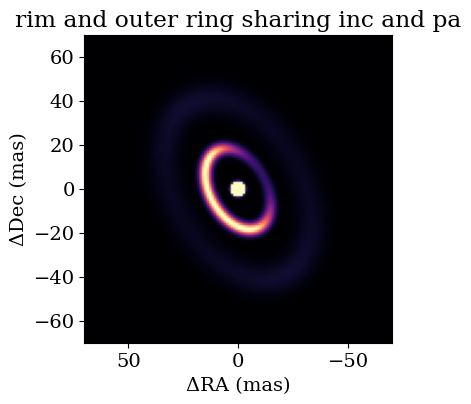

In [12]:
def coplanar_disk(inc, pa, outer_diam, outer_flux):
    return System(
        star=PointSource(),
        rim=ModulatedGaussianRim(
            diam=40.0, fwhm=4.0, inc=inc, pa=pa, az_amps=0.7, az_pas=120.0, flux=0.5
        ),
        outer=ModulatedGaussianRim(diam=outer_diam, fwhm=12.0, inc=inc, pa=pa, flux=outer_flux),
    )


plot_model(
    coplanar_disk(inc=50.0, pa=30.0, outer_diam=90.0, outer_flux=0.3),
    fov_mas=140.0,
    npix=128,
    saturate=0.995,
    title="rim and outer ring sharing inc and pa",
)
plt.show()

Positions don't need a function at all, because nesting already ties them. Parts that should move together belong in their own `System`, as the companion and its disk did earlier: `comp.dra` and `comp.ddec` move the core and the disk as one, and there is no way for them to drift apart during a fit.


## Things to keep in mind

* **Keep one flux fixed.** Only flux ratios are measurable, so leave the reference part (usually the star) at `flux=1`. If every flux is free, the overall scale is unconstrained and samplers will wander.
* **Names become parameter names.** Component names must be valid Python identifiers, and can't clash with `System` attributes such as `flux`, `model` or `set`.
* **Fluxes are positive.** Models refuse negative fluxes, `numpyro_model` refuses flux priors that allow them, and the grid tools refuse negative flux axes. Only the unconstrained optimizer inside `optimized_contrast_grid` may report a negative best fit, for the reason given above.
* **Say which parameter is the brightness.** Pass `flux_param=` to `optimized_contrast_grid`, `laplace_contrast_uncertainty_grid`, `optimized_likelihood_grid` and `absil_limits`. If you leave it out, a key named `flux` or a single key ending in `.flux` is used; if the choice would depend on the order of the keys, you get a deprecation warning.
* **Images are for looking, not fitting.** `render` and `plot_model` are there to check what a model looks like. Fits always use the exact analytic visibilities.